In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
users = pd.read_csv("users.csv")
subscriptions = pd.read_csv("subscriptions.csv")
payments = pd.read_csv("payments.csv")
events = pd.read_csv("events.csv")

## Convert Date Columns

In [4]:
users["signup_date"] = pd.to_datetime(users["signup_date"])

subscriptions["start_date"] = pd.to_datetime(subscriptions["start_date"])
subscriptions["end_date"] = pd.to_datetime(subscriptions["end_date"])

payments["payment_date"] = pd.to_datetime(payments["payment_date"])

events["event_date"] = pd.to_datetime(events["event_date"])

In [5]:
print(users.shape)
print(subscriptions.shape)
print(payments.shape)
print(events.shape)

(10000, 5)
(2480, 6)
(18482, 5)
(200000, 5)


## MRR Growth Trend

In [6]:
payments_success = payments[payments["payment_status"] == "success"].copy()
# Whenever filtering rows, always write .copy().

payments_success["month"] = payments_success["payment_date"].dt.to_period("M")

mrr = payments_success.groupby("month")["amount"].sum().reset_index()

mrr["month"] = mrr["month"].astype(str)

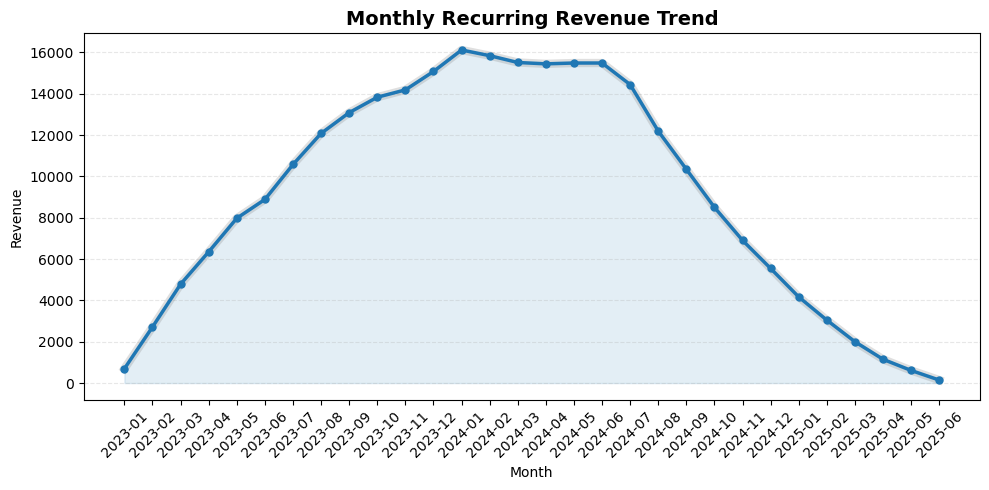

In [7]:
import matplotlib.pyplot as plt

months = mrr["month"]
revenue = mrr["amount"]

plt.figure(figsize=(10,5))

# shadow line (depth effect)
plt.plot(months, revenue,
         linewidth=6,
         color="gray",
         alpha=0.25)

# main line
plt.plot(months, revenue,
         color="#1f77b4",
         linewidth=2.5,
         marker="o",
         markersize=5)

# soft area fill
plt.fill_between(months, revenue,
                 color="#1f77b4",
                 alpha=0.12)

plt.xticks(rotation=45)

plt.title("Monthly Recurring Revenue Trend",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Month")
plt.ylabel("Revenue")

# cleaner grid
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

## CLV Distribution

In [9]:
clv = payments_success.merge(subscriptions, on = "subscription_id")

clv = clv.groupby("user_id")["amount"].sum().reset_index()

clv.rename(columns={"amount":"CLV"},inplace=True)

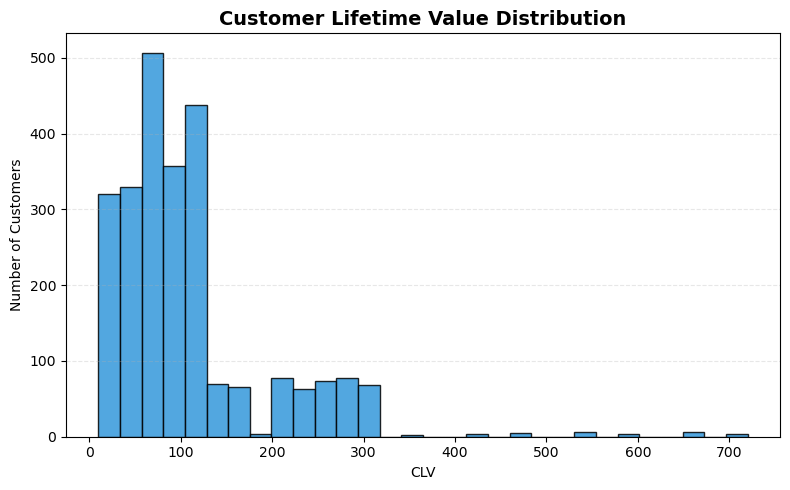

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(clv["CLV"],
         bins=30,
         color="#3498DB",
         edgecolor="black",
         alpha=0.85)

plt.title("Customer Lifetime Value Distribution",
          fontsize=14,
          fontweight="bold")

plt.xlabel("CLV")
plt.ylabel("Number of Customers")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## Churn Rate Trend

In [11]:
subscriptions["start_month"] = subscriptions["start_date"].dt.to_period("M")

# size - counts rows in each group
# unstack - pivots the status values into columns
# (fill_value = 0) - ensures missing values become 0 instead of NaN
churn = subscriptions.groupby(["start_month","status"]).size().unstack(fill_value = 0)

churn["churn_rate"] = churn["cancelled"] / (churn["cancelled"] + churn["active"])

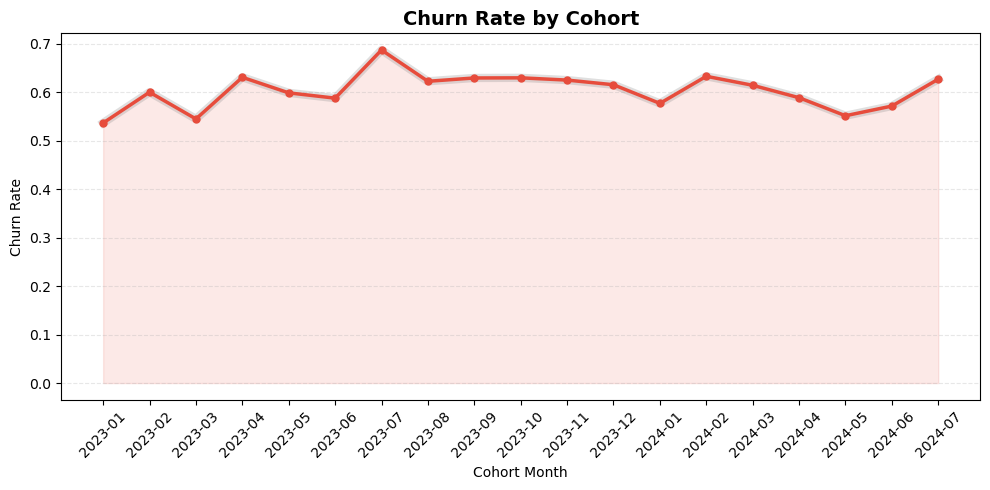

In [12]:
import matplotlib.pyplot as plt

months = churn.index.astype(str)
rates = churn["churn_rate"]

plt.figure(figsize=(10,5))

# shadow line
plt.plot(months, rates,
         linewidth=6,
         color="gray",
         alpha=0.25)

# main line
plt.plot(months, rates,
         color="#E74C3C",
         linewidth=2.5,
         marker="o",
         markersize=5)

# soft fill
plt.fill_between(months, rates,
                 color="#E74C3C",
                 alpha=0.12)

plt.xticks(rotation=45)

plt.title("Churn Rate by Cohort",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Cohort Month")
plt.ylabel("Churn Rate")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## Cohort Retention Heatmap

In [13]:
# cohort month

events["activity_month"] = events["event_date"].dt.to_period("M")
users["cohort_month"] = users["signup_date"].dt.to_period("M")

# merging
cohort = events.merge(users[["user_id","cohort_month"]], on = "user_id")

# Calculate months since signup

cohort["months_since_signup"] = (
                cohort["activity_month"] - cohort["cohort_month"]
).apply(lambda x:x.n)

# Cohort users

cohort_data = cohort.groupby(
            ["cohort_month","months_since_signup"]
)["user_id"].nunique().reset_index()

# Pivot table

cohort_table = cohort_data.pivot(
    index = "cohort_month",
    columns = "months_since_signup",
    values = "user_id"
)

# Normalize by cohort size

cohort_size = users.groupby("cohort_month")["user_id"].nunique()

retention = cohort_table.divide(cohort_size, axis = 0)

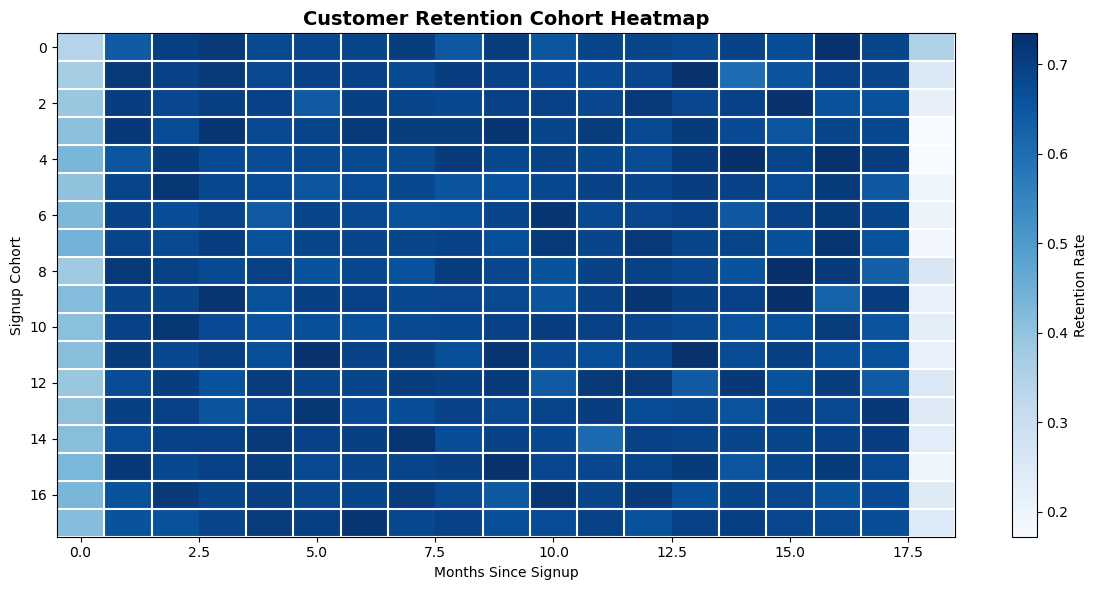

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,6))

heatmap = plt.imshow(retention,
                     cmap="Blues",
                     aspect="auto")

plt.colorbar(heatmap, label="Retention Rate")

# grid lines between cells
plt.gca().set_xticks(np.arange(-.5, retention.shape[1], 1), minor=True)
plt.gca().set_yticks(np.arange(-.5, retention.shape[0], 1), minor=True)

plt.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
plt.tick_params(which="minor", bottom=False, left=False)

plt.title("Customer Retention Cohort Heatmap",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Months Since Signup")
plt.ylabel("Signup Cohort")

plt.tight_layout()
plt.show()